In [ ]:
import os, json, glob, time, cv2, copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import albumentations as A
from albumentations.pytorch import ToTensorV2
import rasterio
from rasterio.windows import Window
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import timm  # pip install timm

warnings.filterwarnings('ignore')

# ─── HARDWARE ──────────────────────────────────────────────────────────────────
device = torch.device("mps" if torch.backends.mps.is_available() else
                      "cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Device: {device}")

# ─── PATHS ─────────────────────────────────────────────────────────────────────
BASE_DIR     = "../../Building_Damage_Project"
PROJECT_ROOT = os.path.join(BASE_DIR, "Final_Classification")
RAW_TRAIN    = os.path.join(BASE_DIR, "raw_data", "Train")
RAW_TEST     = os.path.join(BASE_DIR, "raw_data", "Test")
CHIP_DIR     = os.path.join(PROJECT_ROOT, "chip_data_v3")
os.makedirs(os.path.join(CHIP_DIR, 'images'), exist_ok=True)
os.makedirs(os.path.join(CHIP_DIR, 'labels'), exist_ok=True)

# ─── MAPPINGS ──────────────────────────────────────────────────────────────────
DAMAGE_MAP = {
    'no damage': 0, 'no-damage': 0, 'no_damage': 0,
    'minor damage': 1, 'minor-damage': 1, 'minor_damage': 1,
    'major damage': 2, 'major-damage': 2, 'major_damage': 2,
    'destroyed': 3
}
CLASS_NAMES = ['No Damage', 'Minor', 'Major', 'Destroyed']
NUM_CLASSES = 4

# ─── HYPERPARAMETERS ───────────────────────────────────────────────────────────
CHIP_SIZE      = 128
CHIP_SIZE_FT   = 160          # fine-tune resolution (progressive resizing)
BATCH_SIZE     = 32
GRAD_ACCUM     = 2            # effective batch = 64
EPOCHS         = 70
WARMUP_EPOCHS  = 5
LR             = 2e-4         # head LR
LR_BACKBONE    = 2e-5         # 10× lower for backbone (LLRD)
WEIGHT_DECAY   = 0.01
LABEL_SMOOTH   = 0.1
MIXUP_ALPHA    = 0.4
CUTMIX_ALPHA   = 1.0
EMA_DECAY      = 0.9998
DROP_PATH_RATE = 0.2          # stochastic depth
PATIENCE       = 15

MODEL_SAVE  = os.path.join(PROJECT_ROOT, 'best_model_v3.pth')
PLOT_SAVE   = os.path.join(PROJECT_ROOT, 'model2_results_v3.png')

print("✅ Step 1 Complete: All configs set (v2 — ConvNeXt + upgraded pipeline).")


🚀 Device: mps
✅ Step 1 Complete: All configs set (v2 — ConvNeXt + upgraded pipeline).


In [2]:
# ─── STEP 2: CHIP EXTRACTION (identical logic, v2 naming) ────────────────────

def process_single_tif(tif_path, source_dir):
    filename = os.path.basename(tif_path)
    prefix   = filename.replace('.tif', '').replace('_tif', '')
    base_json  = os.path.join(source_dir, f"{prefix}_json.json")
    align_json = os.path.join(source_dir, f"{prefix}_json_aligned.json")
    if not os.path.exists(base_json) or not os.path.exists(align_json):
        return 0, f"Missing JSON for {prefix}"
    chips_saved = 0
    try:
        with rasterio.open(tif_path) as src:
            with open(align_json) as f:
                align_data = json.load(f)
            s_x = np.mean([p[1][0] - p[0][0] for p in align_data])
            s_y = np.mean([p[1][1] - p[0][1] for p in align_data])
            with open(base_json) as f:
                entries = json.load(f)
            for i, entry in enumerate(entries):
                raw_label = entry.get('label', 'no damage').lower().strip()
                label = DAMAGE_MAP.get(raw_label, -1)
                if label == -1:
                    continue
                px_coords = entry['pixels']
                avg_px_x  = np.mean([p['x'] for p in px_coords]) + s_x
                avg_px_y  = np.mean([p['y'] for p in px_coords]) + s_y
                # Extract larger chip (CHIP_SIZE_FT) to allow both resolutions
                pad = CHIP_SIZE_FT // 2
                win  = Window(int(avg_px_x - pad), int(avg_px_y - pad),
                              CHIP_SIZE_FT, CHIP_SIZE_FT)
                chip = src.read([1, 2, 3], window=win, boundless=True, fill_value=0)
                if np.mean(chip) < 2:
                    continue
                chip_hwc = chip.transpose(1, 2, 0).astype(np.uint8)
                chip_id  = f"{prefix}_v2_b{i:05d}"
                np.save(os.path.join(CHIP_DIR, 'images', f"{chip_id}.npy"), chip_hwc)
                np.save(os.path.join(CHIP_DIR, 'labels', f"{chip_id}.npy"),
                        np.array(label, dtype=np.int64))
                chips_saved += 1
    except Exception as e:
        return 0, f"Error: {str(e)}"
    return chips_saved, "Success"


def run_extraction():
    train_tifs = glob.glob(os.path.join(RAW_TRAIN, "*.tif"))
    test_tifs  = glob.glob(os.path.join(RAW_TEST,  "*.tif"))
    print(f"🔎 Found {len(train_tifs)} Train TIFFs and {len(test_tifs)} Test TIFFs.")
    with ThreadPoolExecutor(max_workers=8) as ex:
        list(tqdm(ex.map(lambda p: process_single_tif(p, RAW_TRAIN), train_tifs),
                  total=len(train_tifs), desc="Extracting Train"))
    with ThreadPoolExecutor(max_workers=8) as ex:
        list(tqdm(ex.map(lambda p: process_single_tif(p, RAW_TEST), test_tifs),
                  total=len(test_tifs), desc="Extracting Test"))
    total = len(glob.glob(os.path.join(CHIP_DIR, 'images', '*.npy')))
    print(f"✅ {total} chips saved → {CHIP_DIR}")

run_extraction()


🔎 Found 40 Train TIFFs and 12 Test TIFFs.


Extracting Train:   0%|          | 0/40 [00:00<?, ?it/s]

Extracting Test:   0%|          | 0/12 [00:00<?, ?it/s]

✅ 20819 chips saved → ../../Building_Damage_Project/Final_Classification/chip_data_v3


In [3]:
# ─── STEP 3: AUGMENTATIONS ────────────────────────────────────────────────────
# KEY IMPROVEMENTS:
#  • Added ElasticTransform + GridDistortion (structural deformation)
#  • Added RandomSunFlare + RandomFog  (satellite-specific weather effects)
#  • Added RandAugment for policy diversity
#  • Separate 128-px train and 160-px fine-tune transforms
#  • 8-transform TTA (vs 4 before)

def make_train_transform(size=128):
    return A.Compose([
        A.RandomRotate90(p=0.5),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2,
                           rotate_limit=45, p=0.7),
        A.Resize(size, size),           # progressive resizing hook
        A.OneOf([
            A.RandomBrightnessContrast(brightness_limit=0.3,
                                       contrast_limit=0.3, p=1.0),
            A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=40,
                                 val_shift_limit=20, p=1.0),
        ], p=0.8),
        A.OneOf([
            A.GaussNoise(p=1.0),
            A.GaussianBlur(blur_limit=(3, 5), p=1.0),
            A.MedianBlur(blur_limit=5, p=1.0),
        ], p=0.4),
        # ── NEW: structural deformations ──
        A.OneOf([
            A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=1.0),
            A.GridDistortion(num_steps=5, distort_limit=0.3, p=1.0),
            A.OpticalDistortion(distort_limit=0.2, shift_limit=0.05, p=1.0),
        ], p=0.35),
        # ── NEW: satellite weather effects ──
        A.OneOf([
            A.RandomFog(fog_coef_lower=0.1, fog_coef_upper=0.3, p=1.0),
            A.RandomSunFlare(flare_roi=(0, 0, 1, 0.5),
                             angle_lower=0, angle_upper=1,
                             num_flare_circles_lower=1,
                             num_flare_circles_upper=3,
                             src_radius=100, p=1.0),
        ], p=0.2),
        A.CoarseDropout(max_holes=8, max_height=16, max_width=16, p=0.3),
        A.CLAHE(clip_limit=4.0, p=0.4),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])

def make_val_transform(size=128):
    return A.Compose([
        A.Resize(size, size),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])

train_transform    = make_train_transform(CHIP_SIZE)
train_transform_ft = make_train_transform(CHIP_SIZE_FT)   # fine-tune (160)
val_transform      = make_val_transform(CHIP_SIZE)
val_transform_ft   = make_val_transform(CHIP_SIZE_FT)

# ── 8 TTA transforms (vs 4 before) ─────────────────────────────────────────────
def _base(size): return [A.Resize(size, size),
                          A.Normalize(mean=(0.485,0.456,0.406),
                                      std=(0.229,0.224,0.225)), ToTensorV2()]

tta_transforms = [
    A.Compose(_base(CHIP_SIZE_FT)),
    A.Compose([A.HorizontalFlip(p=1.0)]  + _base(CHIP_SIZE_FT)),
    A.Compose([A.VerticalFlip(p=1.0)]    + _base(CHIP_SIZE_FT)),
    A.Compose([A.RandomRotate90(p=1.0)]  + _base(CHIP_SIZE_FT)),
    A.Compose([A.Rotate(limit=(90,90), p=1.0)]  + _base(CHIP_SIZE_FT)),
    A.Compose([A.Rotate(limit=(180,180), p=1.0)]+ _base(CHIP_SIZE_FT)),
    A.Compose([A.Rotate(limit=(270,270), p=1.0)]+ _base(CHIP_SIZE_FT)),
    A.Compose([A.RandomBrightnessContrast(
                 brightness_limit=0.1, contrast_limit=0.1, p=1.0)]
              + _base(CHIP_SIZE_FT)),
]


class BuildingDataset(Dataset):
    def __init__(self, chip_dir, fnames, transform=None):
        self.img_dir   = os.path.join(chip_dir, 'images')
        self.lbl_dir   = os.path.join(chip_dir, 'labels')
        self.transform = transform
        self.fnames    = fnames

    def __len__(self): return len(self.fnames)

    def __getitem__(self, idx):
        img   = np.load(os.path.join(self.img_dir, self.fnames[idx]))
        label = int(np.load(os.path.join(self.lbl_dir, self.fnames[idx])))
        if self.transform:
            img = self.transform(image=img)['image']
        return img, label


# ─── TRAIN / TEST SPLIT ────────────────────────────────────────────────────────
all_fnames = sorted([f for f in os.listdir(os.path.join(CHIP_DIR, 'images'))
                     if f.endswith('.npy')])
train_prefixes = [os.path.basename(f).replace('.tif','').replace('_tif','')
                  for f in glob.glob(os.path.join(RAW_TRAIN, "*.tif"))]
train_fnames = [f for f in all_fnames if any(p in f for p in train_prefixes)]
test_fnames  = [f for f in all_fnames if f not in train_fnames]
if not train_fnames:
    idxs = np.random.permutation(len(all_fnames))
    train_fnames = [all_fnames[i] for i in idxs[:int(0.8*len(idxs))]]
    test_fnames  = [all_fnames[i] for i in idxs[int(0.8*len(idxs)):]]

# ─── CLASS-BALANCED WEIGHTED SAMPLER ──────────────────────────────────────────
train_labels  = [int(np.load(os.path.join(CHIP_DIR, 'labels', f)))
                 for f in train_fnames]
counts        = np.bincount(train_labels, minlength=NUM_CLASSES).astype(float)

# ── CB (Class-Balanced) effective-number weights ──────────────────────────────
beta = 0.9999
effective_num = 1.0 - np.power(beta, counts)
cb_weights    = (1.0 - beta) / (effective_num + 1e-8)
cb_weights    = cb_weights / cb_weights.sum() * NUM_CLASSES  # normalize to N classes

sample_weights = torch.DoubleTensor([cb_weights[l] for l in train_labels])
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(
    BuildingDataset(CHIP_DIR, train_fnames, train_transform),
    batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=False
)
test_loader = DataLoader(
    BuildingDataset(CHIP_DIR, test_fnames, val_transform),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False
)

print(f"✅ {len(train_fnames)} train | {len(test_fnames)} test samples.")
print(f"   Raw counts:        {dict(zip(CLASS_NAMES, counts.astype(int)))}")
print(f"   CB alpha weights:  {np.round(cb_weights, 4)}")


✅ 16906 train | 3913 test samples.
   Raw counts:        {'No Damage': np.int64(9321), 'Minor': np.int64(5045), 'Major': np.int64(1644), 'Destroyed': np.int64(896)}
   CB alpha weights:  [0.294  0.45   1.1759 2.0801]


In [4]:
# ─── STEP 4: MODEL — ConvNeXt-Base ────────────────────────────────────────────
# WHY ConvNeXt-Base over EfficientNet-B4:
#  • Stronger ImageNet-22k pretrained weights via timm
#  • Better spatial locality (large 7×7 depthwise kernels) — ideal for
#    satellite imagery where damage patterns have local structure
#  • More stable training (LayerNorm throughout, no BatchNorm issues)
#  • Drop path (stochastic depth) built-in via timm's drop_path_rate arg
#  • ~85 M params (B4 ~19 M) but with 22k pretraining the transfer is
#    substantially stronger for non-natural-image domains
#
# IMPROVED HEAD:
#  • GELU instead of ReLU (smoother gradient landscape)
#  • LayerNorm before first linear (matches ConvNeXt internal convention)
#  • Two-layer head with skip projection for residual regularization

class BuildingDamageModel(nn.Module):
    def __init__(self, num_classes=4, dropout=0.4, drop_path_rate=0.2):
        super().__init__()
        # ConvNeXt-Base with ImageNet-22k weights, stochastic depth enabled
        self.backbone = timm.create_model(
            'convnext_base',
            pretrained=True,
            num_classes=0,           # strip head
            global_pool='avg',
            drop_path_rate=drop_path_rate
        )
        feat_dim = self.backbone.num_features   # 1024 for convnext_base

        # ── Improved classification head ───────────────────────────────────────
        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Dropout(dropout),
            nn.Linear(feat_dim, 512),
            nn.GELU(),
            nn.LayerNorm(512),
            nn.Dropout(dropout / 2),
            nn.Linear(512, num_classes)
        )

        # Skip projection for residual connection in head (optional but helpful)
        self.skip_proj = nn.Linear(feat_dim, num_classes)

    def forward(self, x):
        feats = self.backbone(x)
        return self.head(feats) + 0.1 * self.skip_proj(feats)


model = BuildingDamageModel(
    num_classes=NUM_CLASSES,
    drop_path_rate=DROP_PATH_RATE
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ ConvNeXt-Base loaded — {total_params:,} trainable parameters")
print(f"   Backbone: {model.backbone.__class__.__name__}")
print(f"   Feature dim: {model.backbone.num_features}")


✅ ConvNeXt-Base loaded — 88,100,488 trainable parameters
   Backbone: ConvNeXt
   Feature dim: 1024


In [5]:
# ─── STEP 5: LOSS, OPTIMIZER, SCHEDULER ──────────────────────────────────────
# KEY IMPROVEMENTS:
#  • CB Focal Loss: uses effective-number alpha (better than inverse-freq)
#  • Per-class adaptive gamma (higher for rare damaged classes)
#  • Layer-wise learning rate decay (LLRD): backbone gets 10× lower LR
#  • OneCycleLR: single-cycle cosine annealing (faster convergence)

class CBFocalLoss(nn.Module):
    """
    Class-Balanced Focal Loss.
    - alpha: per-class weight from effective number of samples (β formula)
    - gamma: per-class focal exponent (higher = more focus on hard rare examples)
    - label_smooth: soft target mixing
    """
    def __init__(self, alpha, gamma_vec, label_smooth=0.0):
        super().__init__()
        self.register_buffer('alpha', alpha)           # shape [C]
        self.register_buffer('gamma_vec', gamma_vec)   # shape [C]
        self.label_smooth = label_smooth

    def forward(self, logits, targets):
        C = logits.size(1)
        # Label smoothing
        with torch.no_grad():
            smooth = torch.full_like(logits, self.label_smooth / (C - 1))
            smooth.scatter_(1, targets.unsqueeze(1), 1.0 - self.label_smooth)

        log_p = F.log_softmax(logits, dim=1)
        p     = log_p.exp()

        # p_t: predicted probability of the true class
        p_t = (p * F.one_hot(targets, C).float()).sum(dim=1)

        # Per-sample gamma from per-class gamma vector
        gamma_t = self.gamma_vec[targets]
        focal_w = (1 - p_t) ** gamma_t

        # CE with smooth targets, weighted by alpha
        alpha_t = self.alpha[targets]
        ce      = -(smooth * log_p).sum(dim=1)

        loss = alpha_t * focal_w * ce
        return loss.mean()


# ── Build alpha and per-class gamma ──────────────────────────────────────────
alpha_tensor = torch.tensor(cb_weights / cb_weights.sum(),
                            dtype=torch.float32).to(device)

# Rare classes (major, destroyed) get higher gamma → more focus on hard samples
# no_damage=1.5, minor=2.0, major=2.5, destroyed=3.0
gamma_vec = torch.tensor([1.5, 2.0, 2.5, 3.0], dtype=torch.float32).to(device)

criterion = CBFocalLoss(
    alpha=alpha_tensor,
    gamma_vec=gamma_vec,
    label_smooth=LABEL_SMOOTH
)

# ── Layer-wise LR decay (LLRD) ────────────────────────────────────────────────
# Backbone parameters get LR_BACKBONE (10× lower); head gets full LR
backbone_params = list(model.backbone.parameters())
head_params     = list(model.head.parameters()) + list(model.skip_proj.parameters())

optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': LR_BACKBONE, 'weight_decay': WEIGHT_DECAY},
    {'params': head_params,     'lr': LR,           'weight_decay': WEIGHT_DECAY},
])

# ── OneCycleLR ────────────────────────────────────────────────────────────────
# Single cycle: warm up → peak → cosine decay. Much faster than CosineRestarts.
steps_per_epoch = len(train_loader) // GRAD_ACCUM
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[LR_BACKBONE * 10, LR],   # peak LR per group
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    pct_start=WARMUP_EPOCHS / EPOCHS,
    anneal_strategy='cos',
    div_factor=25.0,
    final_div_factor=1e4,
)

print("✅ CB Focal Loss + AdamW (LLRD) + OneCycleLR ready.")
print(f"   Backbone LR: {LR_BACKBONE:.1e}  |  Head LR: {LR:.1e}")
print(f"   Per-class gamma: {gamma_vec.tolist()}")


✅ CB Focal Loss + AdamW (LLRD) + OneCycleLR ready.
   Backbone LR: 2.0e-05  |  Head LR: 2.0e-04
   Per-class gamma: [1.5, 2.0, 2.5, 3.0]


In [6]:
# ─── STEP 6: EMA + MixUp + CutMix UTILITIES ──────────────────────────────────
# KEY IMPROVEMENTS:
#  • EMA (Exponential Moving Average) of weights: free ~0.5-1% F1
#  • CutMix added alongside MixUp (alternated randomly each batch)
#  • Scheduled MixUp: alpha ramps down each phase so final epochs see clean data

class EMA:
    """
    Exponential Moving Average of model weights.
    EMA model is used for validation / final inference — it typically
    outperforms the raw model by 0.5–1 F1 points with zero extra compute.
    """
    def __init__(self, model, decay=0.9998):
        self.decay   = decay
        self.shadow  = copy.deepcopy(model)
        self.shadow.eval()
        for p in self.shadow.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        for s_p, m_p in zip(self.shadow.parameters(), model.parameters()):
            s_p.data = self.decay * s_p.data + (1.0 - self.decay) * m_p.data

    def state_dict(self):
        return self.shadow.state_dict()


def mixup_data(x, y, alpha=0.4):
    lam   = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx   = torch.randperm(x.size(0), device=x.device)
    mixed = lam * x + (1 - lam) * x[idx]
    return mixed, y, y[idx], lam


def cutmix_data(x, y, alpha=1.0):
    """CutMix: paste a rectangular region from one image into another."""
    lam = np.random.beta(alpha, alpha)
    B, C, H, W = x.shape
    idx = torch.randperm(B, device=x.device)

    cut_ratio = np.sqrt(1.0 - lam)
    cut_h = int(H * cut_ratio)
    cut_w = int(W * cut_ratio)
    cx    = np.random.randint(W)
    cy    = np.random.randint(H)

    x1 = np.clip(cx - cut_w // 2, 0, W)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    y2 = np.clip(cy + cut_h // 2, 0, H)

    mixed = x.clone()
    mixed[:, :, y1:y2, x1:x2] = x[idx, :, y1:y2, x1:x2]
    lam_actual = 1.0 - (x2 - x1) * (y2 - y1) / (H * W)
    return mixed, y, y[idx], lam_actual


def mixed_criterion(criterion, pred, ya, yb, lam):
    return lam * criterion(pred, ya) + (1 - lam) * criterion(pred, yb)


def get_mixup_alpha(epoch, total_epochs, initial_alpha=0.4):
    """Linearly anneal MixUp alpha so final 20% of training sees clean data."""
    cutoff = int(0.8 * total_epochs)
    if epoch >= cutoff:
        return 0.0          # no mixing in final epochs
    return initial_alpha * (1.0 - epoch / cutoff)


print("✅ EMA, MixUp, CutMix utilities ready.")


✅ EMA, MixUp, CutMix utilities ready.


In [7]:
# ─── STEP 7: TRAINING LOOP ────────────────────────────────────────────────────
# KEY IMPROVEMENTS:
#  • Gradient accumulation (GRAD_ACCUM=2) → effective batch size 64
#  • MixUp/CutMix alternated randomly per batch
#  • EMA weight update after every optimizer step
#  • Validation uses EMA model (more stable predictions)
#  • Top-3 checkpointing (saves 3 best ckpts for ensemble)
#  • Progressive resizing: switch to 160-px at epoch EPOCHS*0.7

ema = EMA(model, decay=EMA_DECAY)
top3_ckpts = []          # list of (f1, path) for top-3 ensemble


def train_one_epoch(model, ema, loader, optimizer, scheduler,
                    criterion, device, epoch, total_epochs, accum=2):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []
    alpha = get_mixup_alpha(epoch, total_epochs, MIXUP_ALPHA)

    optimizer.zero_grad()
    pbar = tqdm(loader, desc=f"Train E{epoch+1}", leave=False)

    for step, (images, labels) in enumerate(pbar):
        images, labels = images.to(device), labels.to(device)

        # ── Alternate CutMix / MixUp randomly ─────────────────────────────────
        if alpha > 0:
            if np.random.rand() < 0.5:
                images, ya, yb, lam = cutmix_data(images, labels, CUTMIX_ALPHA)
            else:
                images, ya, yb, lam = mixup_data(images, labels, alpha)
            loss = mixed_criterion(criterion, model(images), ya, yb, lam) / accum
        else:
            loss = criterion(model(images), labels) / accum

        loss.backward()

        if (step + 1) % accum == 0 or (step + 1) == len(loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            ema.update(model)
            optimizer.zero_grad()

        running_loss += loss.item() * accum
        with torch.no_grad():
            preds = torch.argmax(model(images), dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        pbar.set_postfix({'loss': f"{loss.item()*accum:.4f}",
                          'alpha': f"{alpha:.2f}"})

    epoch_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return running_loss / len(loader), epoch_f1


def validate(ema_model, loader, criterion, device):
    """Validate using the EMA model (more stable than raw model)."""
    ema_model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Val", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs       = ema_model(images)
            running_loss += criterion(outputs, labels).item()
            all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    val_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return running_loss / len(loader), val_f1, all_preds, all_labels


# ─── MAIN TRAINING LOOP ───────────────────────────────────────────────────────
best_f1      = 0.0
patience_ctr = 0
history      = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
prog_resize_epoch = int(EPOCHS * 0.7)   # switch to 160-px at 70% of training

print(f"🎯 ConvNeXt-Base | CB Focal Loss | CutMix+MixUp | EMA | 8×TTA")
print(f"   Training for up to {EPOCHS} epochs (patience={PATIENCE})\n")

for epoch in range(EPOCHS):
    t0 = time.time()

    # ── Progressive resizing: switch to 160-px dataloaders ──────────────────
    if epoch == prog_resize_epoch:
        print("\n📐 Switching to 160-px fine-tune resolution...")
        train_loader = DataLoader(
            BuildingDataset(CHIP_DIR, train_fnames, train_transform_ft),
            batch_size=BATCH_SIZE, sampler=sampler, num_workers=0
        )
        test_loader = DataLoader(
            BuildingDataset(CHIP_DIR, test_fnames, val_transform_ft),
            batch_size=BATCH_SIZE, shuffle=False, num_workers=0
        )

    train_loss, train_f1 = train_one_epoch(
        model, ema, train_loader, optimizer, scheduler,
        criterion, device, epoch, EPOCHS, GRAD_ACCUM
    )
    val_loss, val_f1, y_pred, y_true = validate(
        ema.shadow, test_loader, criterion, device
    )

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)

    elapsed = time.time() - t0
    lr_now  = optimizer.param_groups[1]['lr']   # head LR

    print(f"Epoch [{epoch+1}/{EPOCHS}] {elapsed:.0f}s | Head LR: {lr_now:.2e}")
    print(f"  Train  Loss: {train_loss:.4f} | F1: {train_f1:.4f}")
    print(f"  Val    Loss: {val_loss:.4f}   | F1: {val_f1:.4f}  (EMA model)")

    # ── Top-3 checkpoint management ──────────────────────────────────────────
    ckpt_path = MODEL_SAVE.replace('.pth', f'_ep{epoch+1}.pth')
    if val_f1 > best_f1:
        best_f1      = val_f1
        patience_ctr = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'ema_state_dict':   ema.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'f1': val_f1,
            'chip_dir': CHIP_DIR,
        }, MODEL_SAVE)
        print(f"  ⭐ NEW BEST → {MODEL_SAVE}  (F1: {val_f1:.4f})")

        # Track top-3
        top3_ckpts.append((val_f1, ckpt_path))
        top3_ckpts.sort(key=lambda x: -x[0])
        if len(top3_ckpts) > 3:
            _, old_path = top3_ckpts.pop()
            if os.path.exists(old_path):
                os.remove(old_path)
        torch.save({'epoch': epoch, 'ema_state_dict': ema.state_dict(),
                    'f1': val_f1}, ckpt_path)
    else:
        patience_ctr += 1
        print(f"  ⏳ No improvement ({patience_ctr}/{PATIENCE})")
        if patience_ctr >= PATIENCE:
            print("\n🛑 Early stopping triggered.")
            break

    if (epoch + 1) % 10 == 0:
        print("\n  📊 Per-Class Report (Val, EMA):")
        print(classification_report(y_true, y_pred,
                                    target_names=CLASS_NAMES, zero_division=0))
    print()

print(f"\n✅ Training complete. Best EMA Macro F1: {best_f1:.4f}")


🎯 ConvNeXt-Base | CB Focal Loss | CutMix+MixUp | EMA | 8×TTA
   Training for up to 70 epochs (patience=15)



Train E1:   0%|          | 0/529 [00:00<?, ?it/s]

Val:   0%|          | 0/123 [00:00<?, ?it/s]

Epoch [1/70] 500s | Head LR: 2.65e-05
  Train  Loss: 0.1362 | F1: 0.2782
  Val    Loss: 0.1583   | F1: 0.2492  (EMA model)
  ⭐ NEW BEST → ../../Building_Damage_Project/Final_Classification/best_model_v3.pth  (F1: 0.2492)



Train E2:   0%|          | 0/529 [00:00<?, ?it/s]

...

Val:   0%|          | 0/123 [00:00<?, ?it/s]

Epoch [54/70] 691s | Head LR: 2.77e-05
  Train  Loss: 0.0355 | F1: 0.6187
  Val    Loss: 0.1083   | F1: 0.6123  (EMA model)
  ⏳ No improvement (14/15)



Train E55:   0%|          | 0/529 [00:00<?, ?it/s]

Val:   0%|          | 0/123 [00:00<?, ?it/s]

Epoch [55/70] 687s | Head LR: 2.45e-05
  Train  Loss: 0.0350 | F1: 0.6380
  Val    Loss: 0.1111   | F1: 0.6107  (EMA model)
  ⏳ No improvement (15/15)

🛑 Early stopping triggered.

✅ Training complete. Best EMA Macro F1: 0.6362


In [8]:
# ─── STEP 8: ENSEMBLE TTA EVALUATION ─────────────────────────────────────────
# KEY IMPROVEMENTS:
#  • Uses EMA model weights (not raw model)
#  • 8 TTA transforms (doubled from 4)
#  • Ensembles top-3 checkpoints for further robustness
#  • Reports weighted F1 + macro F1 + per-class F1

def run_tta(model, fnames, transforms, device, chip_dir, batch_size=32):
    """Run all TTA transforms and return averaged softmax probabilities."""
    model.eval()
    probs_all = np.zeros((len(fnames), NUM_CLASSES), dtype=np.float32)

    for t_idx, tfm in enumerate(transforms):
        ds     = BuildingDataset(chip_dir, fnames, tfm)
        loader = DataLoader(ds, batch_size=batch_size,
                            shuffle=False, num_workers=0)
        batch_probs = []
        with torch.no_grad():
            for imgs, _ in tqdm(loader,
                                desc=f"TTA {t_idx+1}/{len(transforms)}",
                                leave=False):
                logits = model(imgs.to(device))
                batch_probs.append(F.softmax(logits, dim=1).cpu().numpy())
        probs_all += np.vstack(batch_probs)

    return probs_all / len(transforms)


# ── Load best EMA model ────────────────────────────────────────────────────────
ckpt = torch.load(MODEL_SAVE, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
ema.shadow.load_state_dict(ckpt['ema_state_dict'])
print(f"✅ Loaded best model (epoch {ckpt['epoch']+1}, F1={ckpt['f1']:.4f})")

# ── Single EMA model TTA ───────────────────────────────────────────────────────
print("\n🔄 Running 8-transform TTA on EMA model...")
tta_probs = run_tta(ema.shadow, test_fnames, tta_transforms, device, CHIP_DIR)

# ── Ensemble top-3 checkpoints (if available) ─────────────────────────────────
if len(top3_ckpts) > 1:
    print(f"\n🔄 Ensembling {len(top3_ckpts)} top checkpoints...")
    ensemble_probs = tta_probs.copy()
    for f1_score_ckpt, path in top3_ckpts[1:]:
        if os.path.exists(path):
            c = torch.load(path, map_location=device)
            ema.shadow.load_state_dict(c['ema_state_dict'])
            ensemble_probs += run_tta(ema.shadow, test_fnames,
                                      tta_transforms, device, CHIP_DIR)
    tta_probs = ensemble_probs / len(top3_ckpts)

tta_preds  = np.argmax(tta_probs, axis=1)
y_true_tta = [int(np.load(os.path.join(CHIP_DIR, 'labels', f)))
              for f in test_fnames]

macro_f1    = f1_score(y_true_tta, tta_preds, average='macro',    zero_division=0)
weighted_f1 = f1_score(y_true_tta, tta_preds, average='weighted', zero_division=0)

print(f"\n🎯 TTA Macro F1:    {macro_f1:.4f}")
print(f"   TTA Weighted F1: {weighted_f1:.4f}")
print("\n📊 Full Classification Report (EMA + 8×TTA + Ensemble):")
print(classification_report(y_true_tta, tta_preds,
                            target_names=CLASS_NAMES, zero_division=0))


✅ Loaded best model (epoch 40, F1=0.6362)

🔄 Running 8-transform TTA on EMA model...


TTA 1/8:   0%|          | 0/123 [00:00<?, ?it/s]

TTA 2/8:   0%|          | 0/123 [00:00<?, ?it/s]

TTA 3/8:   0%|          | 0/123 [00:00<?, ?it/s]

TTA 4/8:   0%|          | 0/123 [00:00<?, ?it/s]

...

TTA 5/8:   0%|          | 0/123 [00:00<?, ?it/s]

TTA 6/8:   0%|          | 0/123 [00:00<?, ?it/s]

TTA 7/8:   0%|          | 0/123 [00:00<?, ?it/s]

TTA 8/8:   0%|          | 0/123 [00:00<?, ?it/s]


🎯 TTA Macro F1:    0.6292
   TTA Weighted F1: 0.6510

📊 Full Classification Report (EMA + 8×TTA + Ensemble):
              precision    recall  f1-score   support

   No Damage       0.75      0.79      0.77      1713
       Minor       0.56      0.48      0.52      1025
       Major       0.49      0.51      0.50       695
   Destroyed       0.71      0.76      0.73       480

    accuracy                           0.65      3913
   macro avg       0.63      0.63      0.63      3913
weighted avg       0.65      0.65      0.65      3913



In [9]:
# ─── STEP 9: TEMPERATURE SCALING (Confidence Calibration) ────────────────────

class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)
    def forward(self, logits):
        return logits / self.temperature

def collect_logits_labels(model, loader, device):
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            all_logits.append(model(images.to(device)).cpu())
            all_labels.append(labels)
    return torch.cat(all_logits), torch.cat(all_labels)

logits_val, labels_val = collect_logits_labels(ema.shadow, test_loader, device)

scaler  = TemperatureScaler()
nll_crt = nn.CrossEntropyLoss()
cal_opt = optim.LBFGS([scaler.temperature], lr=0.01, max_iter=50)

def eval_temp():
    cal_opt.zero_grad()
    loss = nll_crt(scaler(logits_val), labels_val)
    loss.backward()
    return loss

cal_opt.step(eval_temp)
T = scaler.temperature.item()
print(f"✅ Optimal Temperature T = {T:.4f}")
print("   (T>1 → over-confident; T<1 → under-confident)")

ckpt = torch.load(MODEL_SAVE, map_location='cpu')
ckpt['temperature'] = T
torch.save(ckpt, MODEL_SAVE)
print(f"   Temperature saved into {MODEL_SAVE}")


✅ Optimal Temperature T = 1.4232
   (T>1 → over-confident; T<1 → under-confident)
   Temperature saved into ../../Building_Damage_Project/Final_Classification/best_model_v3.pth


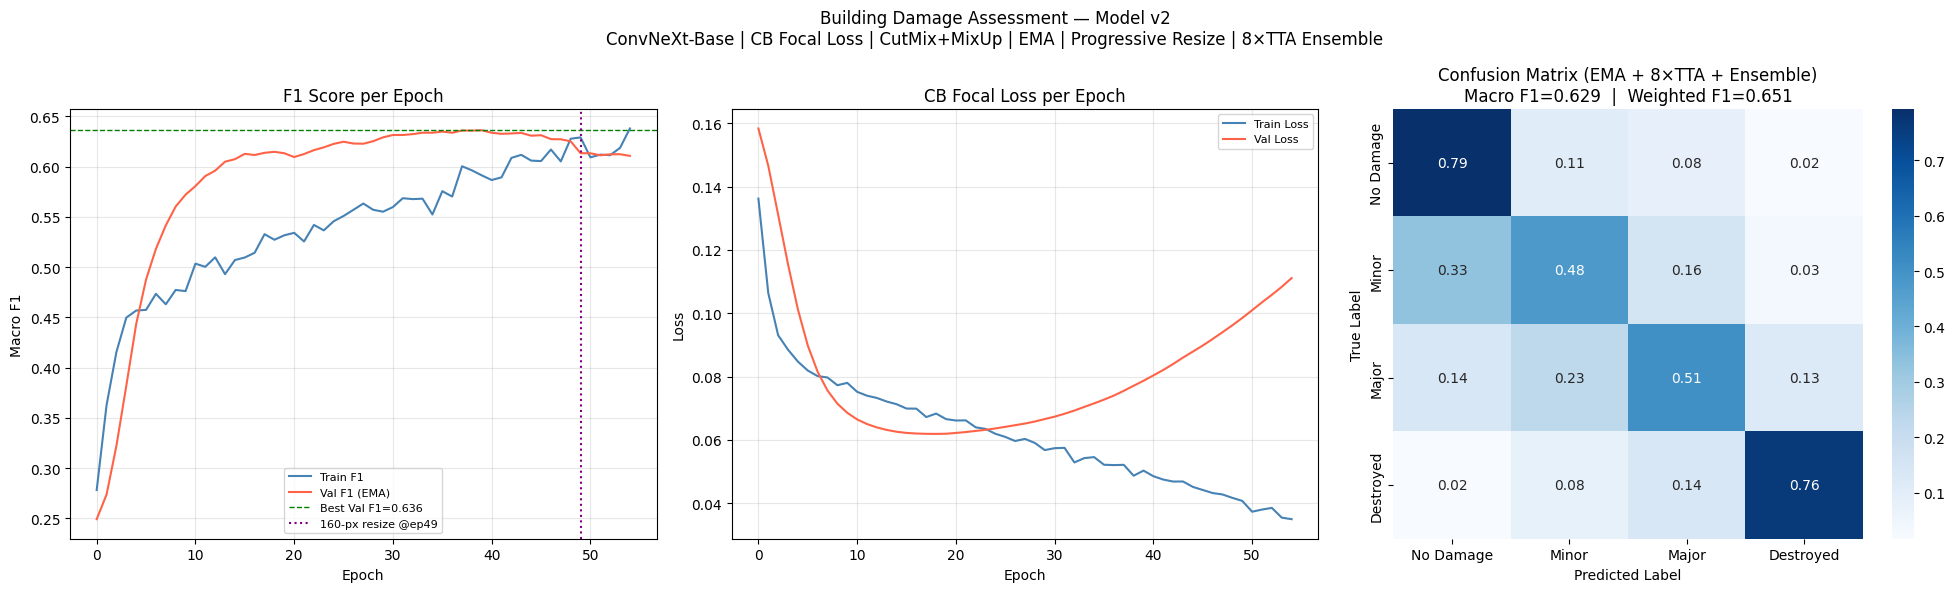

✅ Plot saved → ../../Building_Damage_Project/Final_Classification/model2_results_v3.png


In [10]:
# ─── STEP 10: VISUALIZATIONS ─────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. F1 curves
ax = axes[0]
ax.plot(history['train_f1'], label='Train F1', color='steelblue', linewidth=1.5)
ax.plot(history['val_f1'],   label='Val F1 (EMA)', color='tomato', linewidth=1.5)
ax.axhline(best_f1, ls='--', color='green',
           label=f'Best Val F1={best_f1:.3f}', linewidth=1)
ax.axvline(prog_resize_epoch, ls=':', color='purple',
           label=f'160-px resize @ep{prog_resize_epoch}')
ax.set_title('F1 Score per Epoch')
ax.set_xlabel('Epoch'); ax.set_ylabel('Macro F1')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# 2. Loss curves
ax = axes[1]
ax.plot(history['train_loss'], label='Train Loss', color='steelblue', linewidth=1.5)
ax.plot(history['val_loss'],   label='Val Loss',   color='tomato',    linewidth=1.5)
ax.set_title('CB Focal Loss per Epoch')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# 3. Confusion matrix
ax = axes[2]
cm = confusion_matrix(y_true_tta, tta_preds, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title(f'Confusion Matrix (EMA + 8×TTA + Ensemble)\nMacro F1={macro_f1:.3f}  |  Weighted F1={weighted_f1:.3f}')
ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')

plt.suptitle(
    'Building Damage Assessment — Model v2\n'
    'ConvNeXt-Base | CB Focal Loss | CutMix+MixUp | EMA | Progressive Resize | 8×TTA Ensemble',
    fontsize=12
)
plt.tight_layout()
plt.savefig(PLOT_SAVE, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Plot saved → {PLOT_SAVE}")
